In [73]:
import pandas as pd
import numpy as np
import re
from scripts import mcmc
from scripts import stability_analysis
from scripts import fem_vis
from scripts import fem_solve

#import matplotlib
#matplotlib.use('QtAgg')
%matplotlib inline
import matplotlib.pyplot as plt

NUM = re.compile(r"[-+]?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?")

In [67]:
df = pd.read_csv("results/08_10_2026_mcmc_results/fem_evals.csv")

params = df['Parameters']

print(params)

values = df['Value']
wid = df['Walker']
params_arr = []
values_arr = []
wid_arr = []

for i, param in enumerate(params):
    params_arr.append(mcmc._parse_params(param, n_params=7))
    values_arr.append(values.loc[i])
    wid_arr.append(wid.loc[i])

params_arr = np.asarray(params_arr)
values_arr = np.asarray(values_arr)
wid_arr = np.asarray(wid_arr)

# ignore the 1e+33 values
ignore_args = np.where(values_arr!=1e+33)
values_arr = values_arr[ignore_args]
wid_arr = wid_arr[ignore_args]
params_arr = params_arr[ignore_args]

#print(values_arr)
#print(params_arr)

print(np.mean(values_arr))
print(np.std(values_arr))

0       [  2.10702247, 99.79570889,  7.68709883, 19.04...
1       [ 14.53144484, 98.36261192,  6.30434108,  6.37...
2       [  4.00504785,136.55727936,  3.8895657 , 16.37...
3       [ 18.4151976 ,134.74317681,  7.61282819, 14.95...
4       [ 16.59310433,102.46955523,  9.42911625, 12.51...
                              ...                        
4995    [7.58139762e-02,1.21107599e+02,5.26519935e+00,...
4996    [  8.1886886 ,126.10433396,  3.19781342,  9.04...
4997    [  0.25228004,110.30786635,  5.15125105,  4.93...
4998    [  0.69358437,126.15775312,  8.52417212,  5.98...
4999    [  0.97260673,128.34889678,  4.86017496,  5.22...
Name: Parameters, Length: 5000, dtype: str
2.545154377572354e+31
8.431121552988881e+30


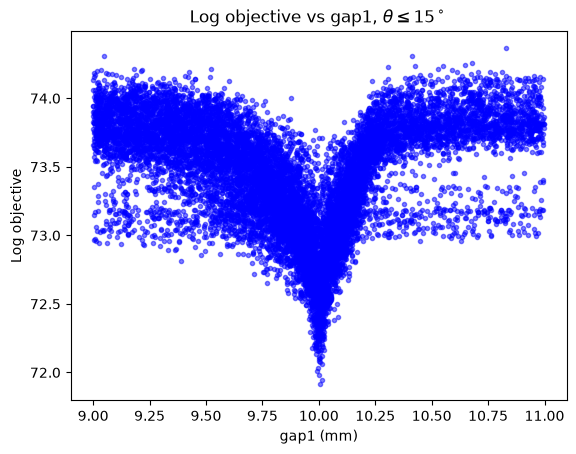

In [19]:
# sort by where theta is
small_theta_args = np.where(theta_vals<=15)
large_theta_args = np.where(theta_vals>15)
gap_1_small_theta = gap1_vals[small_theta_args]
gap_1_large_theta = gap1_vals[large_theta_args]
small_theta_values = values_arr[small_theta_args]
large_theta_values = values_arr[large_theta_args]

fig,ax=plt.subplots()
ax.scatter(gap_1_small_theta, np.log(small_theta_values), marker='.', c='b', alpha=0.5)
#ax.scatter(gap_1_large_theta, np.log(large_theta_values), marker='.', c='b', alpha=0.5)
ax.set_ylabel('Log objective')
ax.set_xlabel('gap1 (mm)')
ax.set_title('Log objective vs gap1, $\\theta\\leq15^\\circ$')
plt.show()

In [20]:
fig,ax=plt.subplots(5, 2, figsize=(6,15))
ax_flat = ax.flatten()
for walker_id in range(10):
    walker_id_args = np.where(wid_arr==walker_id)
    gap1_vals_wid = gap1_vals[walker_id_args]
    values_wid = values_arr[walker_id_args]
    print(f'best result for walker id {walker_id}: {np.min(values_wid)}')
    ax_flat[walker_id].scatter(gap1_vals_wid, np.log(values_wid), marker='.', c='b')
plt.tight_layout()
plt.show()

best result for walker id 0: 1.7119303620295577e+31
best result for walker id 1: 2.2444008368071343e+31
best result for walker id 2: 2.2589633615759326e+31
best result for walker id 3: 1.87403471120526e+31
best result for walker id 4: 2.426209811129673e+31
best result for walker id 5: 2.1271927419587635e+31
best result for walker id 6: 1.9139825267104367e+31
best result for walker id 7: 2.081229384764981e+31
best result for walker id 8: 1.824567283731694e+31
best result for walker id 9: 2.153531502706908e+31


KeyboardInterrupt: 

In [45]:
best = np.argsort(values_arr)
t10_params = params_arr[best][:10]
print(values_arr[best][:10])
print(t10_params)

best_params = params_arr[best][0]
print(best_params)
#print(mcmc.fom(best_params, verbose=True))

[1.40419223e+31 1.43876549e+31 1.45721671e+31 1.45774774e+31
 1.45906749e+31 1.46192404e+31 1.47508475e+31 1.48070023e+31
 1.49294314e+31 1.51157432e+31]
[[  0.16899349 128.74669068   5.83007533   9.41222406  10.9485037
  123.2129638  124.9380107 ]
 [  0.77174051 126.40731498   3.14624887   7.31542385   7.12345959
  125.06403831 124.21403144]
 [  0.25877657 128.67903579   3.23918675   9.15160435   9.4600331
  120.65437761 119.98629185]
 [  1.39531428 129.85867902   3.63980787   8.87375599  10.01921343
  123.60475075 124.72069509]
 [  6.51372124 125.25910064   3.54043696   7.00731821   7.33553891
  120.27789818 119.76489612]
 [  0.29976906 126.80346099   3.42153207   6.9615288    6.91159664
  126.46996416 123.79121764]
 [ 13.67036317 128.43163461   4.07868313   8.79862622   9.16544775
  124.57983389 124.92598285]
 [  1.16933002 125.06472823   4.0255187    7.08504723   6.81367696
  121.4326836  120.40014331]
 [  3.71485018 124.69521278   3.65765288   5.60110377   6.24507505
  123.4746363

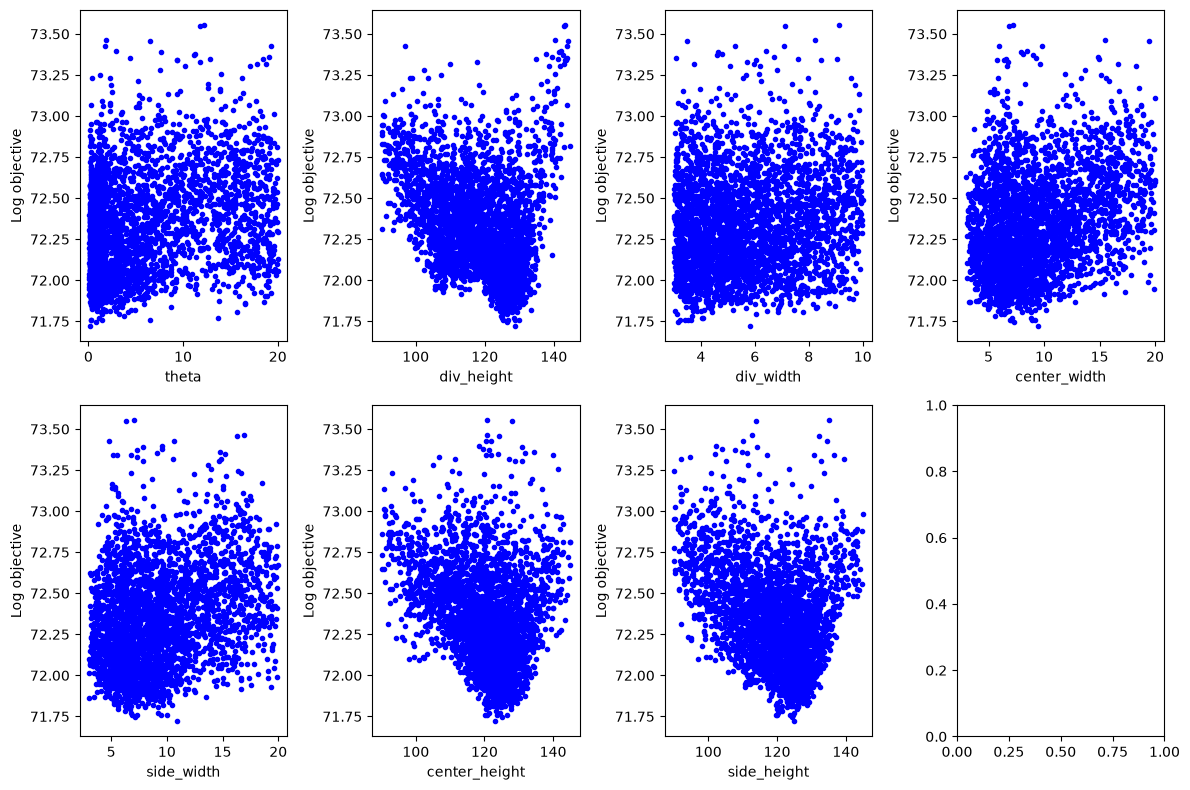

In [55]:
param_names = ['theta', 'div_height', 'div_width', 'center_width', 'side_width', 'center_height', 'side_height']
num_params = len(param_names)
fig, ax = plt.subplots(2,4, figsize=(12,8))
ax_flat = ax.flatten()

for i, name in enumerate(param_names):
    ax_flat[i].scatter(params_arr[:,i], np.log(values_arr), c='b', marker='.')
    ax_flat[i].set_xlabel(name)
    ax_flat[i].set_ylabel("Log objective")

plt.tight_layout()
plt.show()

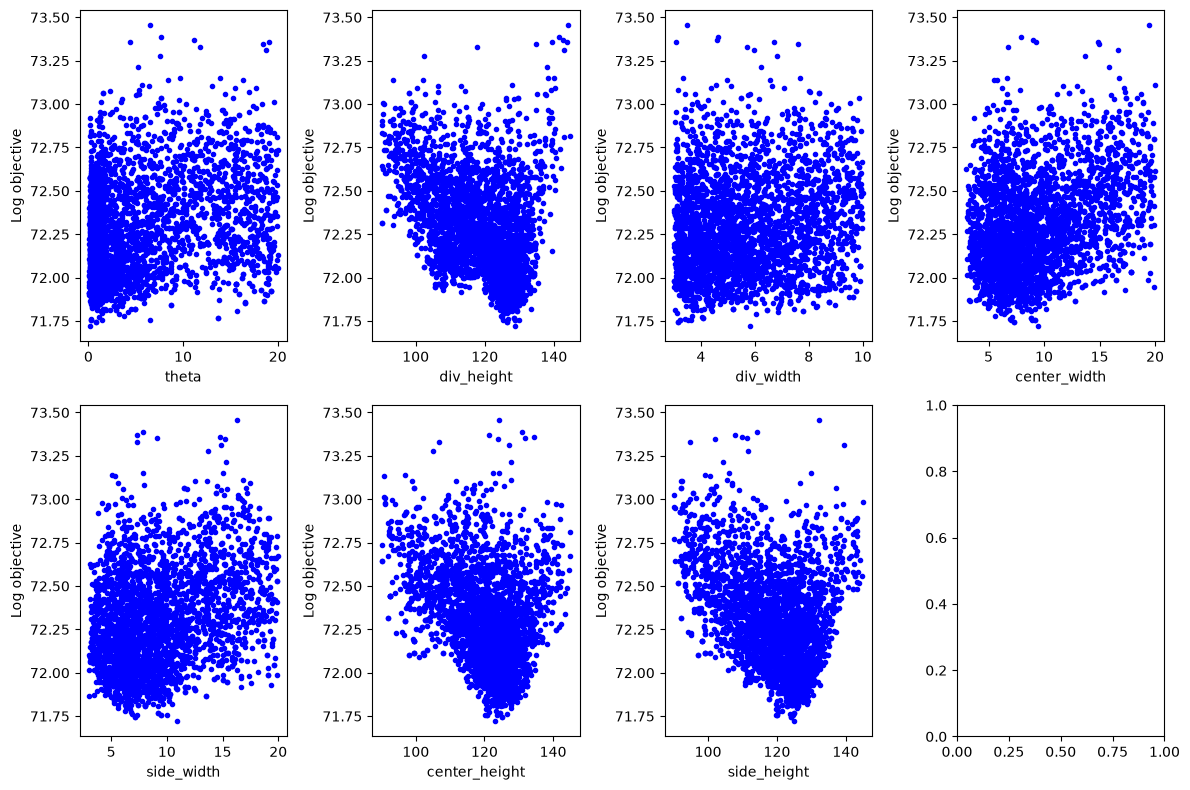

In [57]:
df_all = pd.read_csv('results/08_10_2026_mcmc_results/all_params_all_values.csv')
params_all = df_all['Parameters']
values_all = df_all['Value']
wid_all = df_all['Walker']
params_arr_all = []
values_arr_all = []
wid_arr_all = []

for i, param in enumerate(params_all):
    params_arr_all.append(mcmc._parse_params(param, n_params=7))
    values_arr_all.append(values_all.loc[i])
    wid_arr_all.append(wid_all.loc[i])

params_arr_all = np.asarray(params_arr_all)
values_arr_all = np.asarray(values_arr_all)
wid_arr_all = np.asarray(wid_arr_all)

ignore_args_all = np.where(values_arr_all!=1e+33)
values_arr_all = values_arr_all[ignore_args_all]
wid_arr_all = wid_arr_all[ignore_args_all]
params_arr_all = params_arr_all[ignore_args_all]

param_names = ['theta', 'div_height', 'div_width', 'center_width', 'side_width', 'center_height', 'side_height']
num_params = len(param_names)
fig, ax = plt.subplots(2, 4, figsize=(12,8))
ax_flat = ax.flatten()

for i, name in enumerate(param_names):
    ax_flat[i].scatter(params_arr_all[:,i], np.log(values_arr_all), c='b', marker='.')
    ax_flat[i].set_xlabel(name)
    ax_flat[i].set_ylabel("Log objective")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Log objective')

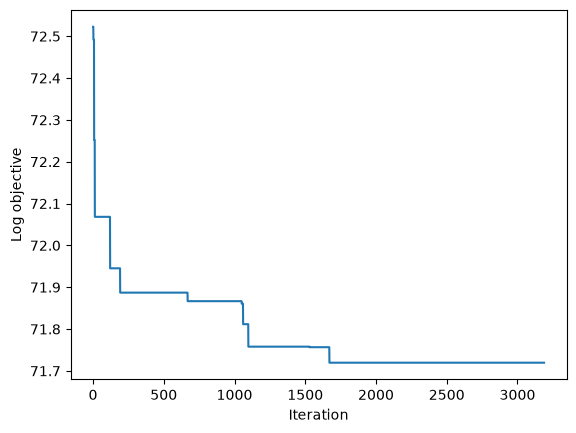

In [62]:
# best so far plot

best_so_far = np.minimum.accumulate(values_arr_all)
fig, ax = plt.subplots()
ax.plot(np.linspace(1, len(best_so_far), len(best_so_far)), np.log(best_so_far))
ax.set_xlabel('Iteration')
ax.set_ylabel('Log objective')

316


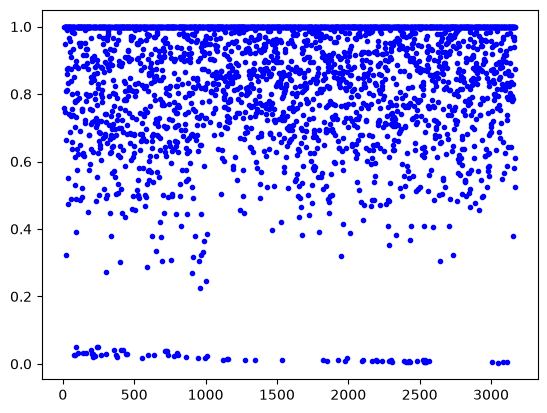

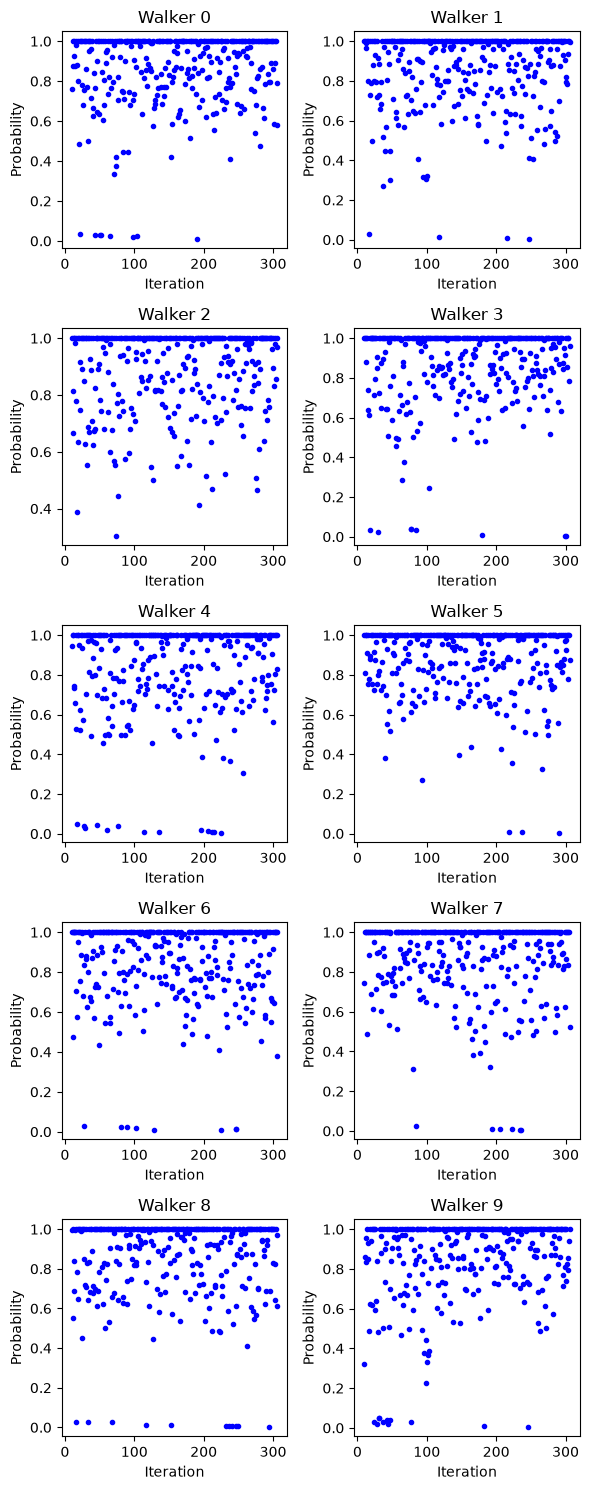

In [58]:
probs = df["AcceptProb"]
fig, ax = plt.subplots()
ax.scatter(probs[-np.isnan(df["AcceptProb"])].index, probs[-np.isnan(df["AcceptProb"])], marker='.', c='b')

probs = np.asarray(probs)
wid_arr = np.asarray(wid)

fig,ax=plt.subplots(5, 2, figsize=(6,15))
ax_flat = ax.flatten()
for walker_id in range(10):
    walker_id_args = np.where(wid_arr==walker_id)
    probs_wid = probs[walker_id_args]
    probs_wid = probs_wid[~np.isnan(probs_wid)]
    inds = np.linspace(10, len(probs_wid)-10, len(probs_wid))
    #print(len(inds))
    #print(f'best result for walker id {walker_id}: {np.min(values_wid)}')
    ax_flat[walker_id].scatter(inds, probs_wid, marker='.', c='b')
    ax_flat[walker_id].set_title(f'Walker {walker_id}')
    ax_flat[walker_id].set_xlabel('Iteration')
    ax_flat[walker_id].set_ylabel('Probability')

print(len(inds))
plt.tight_layout()
plt.show()


range for theta: [np.float64(0.16899349), np.float64(15.69271754)]
range for div_height: [np.float64(123.31083108), np.float64(133.38751764)]
range for div_width: [np.float64(3.03331444), np.float64(8.28171889)]
range for center_width: [np.float64(4.98376597), np.float64(10.20465402)]
range for side_width: [np.float64(5.26640369), np.float64(10.9485037)]
range for center_height: [np.float64(120.27789818), np.float64(127.69415747)]
range for side_height: [np.float64(119.69483965), np.float64(128.64227578)]


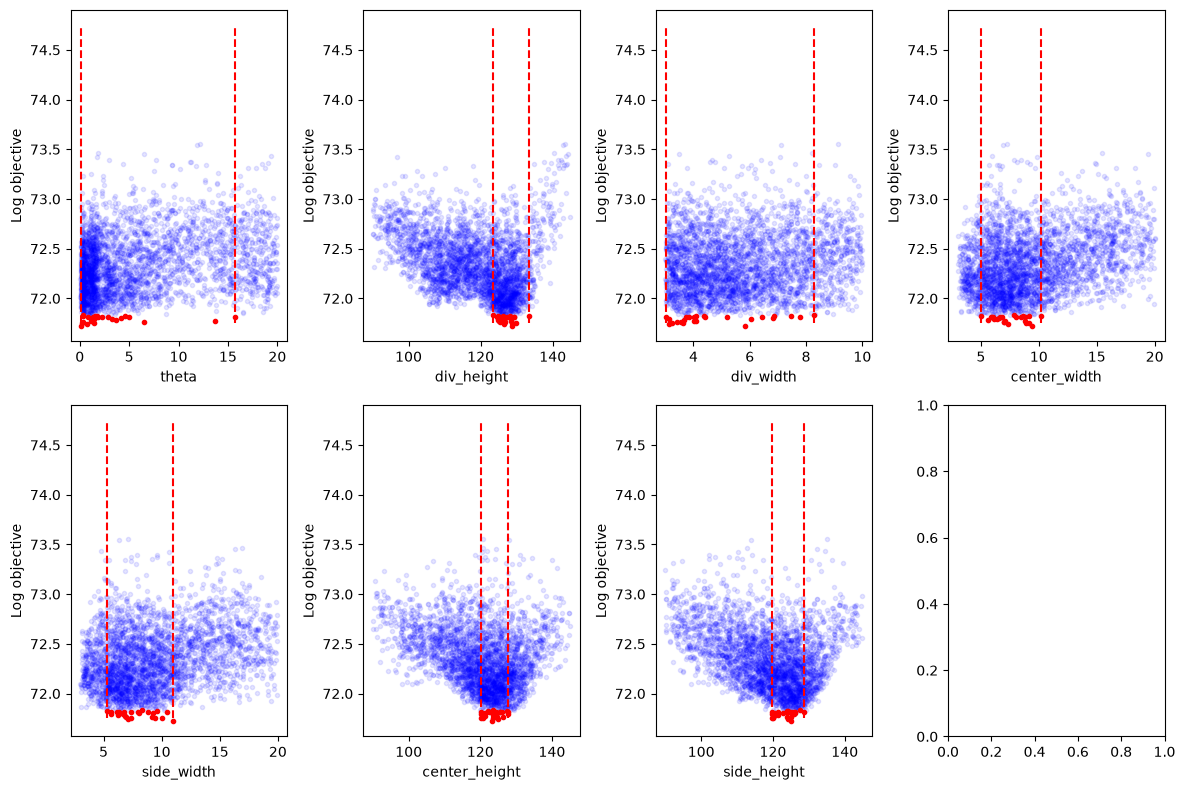

In [59]:
fig, ax = plt.subplots(2, 4, figsize=(12,8))
ax_flat = ax.flatten()

n = 25
tn_params = params_arr[best][:n]

for i, name in enumerate(param_names):
    #print(f'optimal {name}s: {t10_params[:,i]}\n')
    ax_flat[i].scatter(params_arr[:,i], np.log(values_arr), c='b', marker='.', alpha=0.1)
    ax_flat[i].set_xlabel(name)
    ax_flat[i].set_ylabel("Log objective")
    ax_flat[i].vlines([np.min(tn_params[:,i]), np.max(tn_params[:,i])], 71.75, 74.75, colors='r', ls='--')
    print(f'range for {name}: {[np.min(tn_params[:,i]), np.max(tn_params[:,i])]}')
    ax_flat[i].scatter(tn_params[:,i], np.log(values_arr[best][:n]), c='r', marker='.')

plt.tight_layout()
plt.show()

In [35]:
print(mcmc.fom([43.08239729, 128.44919526, 5.33452249, 9.99969355, 6.26901851, 6.59042247, 125.13866136, 123.95102582], verbose=True))
print()
print(mcmc.fom([0, 128.44919526, 5.33452249, 10, 6.26901851, 6.59042247, 125.13866136, 123.95102582], verbose=True))


  x= -0.00 y=  0.00  guess= 15.000  f= 15.008 GHz  C=0.5124  Q=    7618  loc=0.451
  x= -0.58 y=  0.55  guess= 14.173  f= 14.206 GHz  C=0.2609  Q=    7695  loc=0.178
  x= -1.17 y=  1.09  guess= 13.433  f= 13.473 GHz  C=0.2611  Q=    7929  loc=0.173
  x= -1.75 y=  1.64  guess= 12.766  f= 12.819 GHz  C=0.2532  Q=    8328  loc=0.189
  x= -2.33 y=  2.18  guess= 12.162  f= 12.221 GHz  C=0.2080  Q=    8705  loc=0.163
  x= -2.92 y=  2.73  guess= 11.613  f= 11.646 GHz  C=0.2937  Q=    8765  loc=0.260
  x= -3.50 y=  3.27  guess= 11.111  f= 11.169 GHz  C=0.2068  Q=    9208  loc=0.172
  x= -4.08 y=  3.82  guess= 10.651  f= 10.686 GHz  C=0.2231  Q=    9239  loc=0.199
  x= -4.67 y=  4.36  guess= 10.227  f= 10.279 GHz  C=0.2249  Q=    9212  loc=0.142
  x= -5.25 y=  4.91  guess=  9.836  f=  9.892 GHz  C=0.2314  Q=    9487  loc=0.166
  x= -5.83 y=  5.46  guess=  9.474  f=  9.541 GHz  C=0.2089  Q=    9597  loc=0.148
  x= -6.42 y=  6.00  guess=  9.137  f=  9.216 GHz  C=0.1799  Q=    9825  loc=0.160
  x=

In [69]:
# stability analysis

nominal_result, samples, summary=stability_analysis.check_stability(best_params, num_samples=50, theta_err=1, length_err=0.05)
print(nominal_result, samples, summary)

[stability] nominal gaps (mm): [10. 10. 10. 10. 10. 10.]
[stability] tolerances: {'width': 0.05, 'height': 0.05, 'position': 0.05, 'cavity_w': 0.05, 'cavity_h': 0.05, 'angle_deg': 1, 'correlated_parts': False}
[stability] 50 samples x 16 tuning steps
[stability] nominal: FOM=1.40416e+31  meanC=0.2481  meanQ=9180  band 8.100-14.981 GHz (6.6s)
  [1/50] FOM=5.443e+31  minC=0.1059  gapspread=0.1041 mm
  [2/50] FOM=5.105e+31  minC=0.1010  gapspread=0.1126 mm
  [3/50] FOM=6.747e+31  minC=0.0943  gapspread=0.3579 mm
  [4/50] FOM=4.628e+31  minC=0.0950  gapspread=0.1058 mm
  [5/50] FOM=8.761e+31  minC=0.0886  gapspread=0.3521 mm
  [6/50] FOM=7.23e+31  minC=0.0903  gapspread=0.2570 mm
  [7/50] FOM=4.185e+31  minC=0.1204  gapspread=0.1587 mm
  [8/50] FOM=6.488e+31  minC=0.0918  gapspread=0.1607 mm
  [9/50] FOM=7.552e+31  minC=0.0888  gapspread=0.2664 mm
  [10/50] FOM=3.253e+31  minC=0.1400  gapspread=0.1063 mm
  [11/50] FOM=5.094e+31  minC=0.0953  gapspread=0.1611 mm
  [12/50] FOM=5.568e+31  min

In [ ]:
#params_m = mcmc._params_to_m(best_params)
#spec = fem_vis.toaster_spec(params_m, mesh_size=0.001, mesh_uniform=True)
mcmc.sim_sweep([0.16899349, 128.74669068, 5.83007533, 10., 9.41222406,  10.9485037, 123.2129638, 124.9380107], plot_all=True)

#fem_vis.plot_best_modes_magnitude_square(best_params, save='results/08_11_2026_stability_analysis_nominal.png')

TypeError: float() argument must be a string or a real number, not 'list'